# Week 6 Workshop: Bivariate & Multivariate Analysis

## Saber Pro Test Scores - Finding Relationships Between Variables

**Student Name:** Carlos Steven Lozano Quintero

**Date:** 12/03/2026

---

### Workshop Objectives

1. Build a complete correlation matrix analysis of test scores
2. Test if relationships change by institution type or socioeconomic group
3. Generate 5 actionable insights from bivariate analysis

### Dataset

**Saber Pro** is the Colombian national exam for university students. This dataset contains
scores from multiple competency areas, along with demographic information.

**Key columns:**
- Test scores (numeric): `puntaje_global`, `punt_comp_ciud`, `punt_comu_escr`, `punt_ingles`, `punt_lect_crit`, `punt_razo_cuant`
- Grouping variables (categorical): `sexo`, `estrato`, `tipo_col`, `dep_proc`, `year`

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/saber_pro.csv')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset: 25362 rows, 48 columns


,year,dep_nac,cod_dep_nac,ciu_nac,cod_ciu_nac,lon_ciu_nac,lat_ciu_nac,dep_proc,cod_dep_proc,ciu_proc,...,punt_comp_ciud,nivel_comp_ciud,punt_comu_escr,nivel_comu_escr,punt_ingles,nivel_ingles,punt_lect_crit,nivel_lect_crit,punt_razo_cuant,nivel_razo_cuant
0,2018,Sin datos,-89,Sin datos,-89,-89.000000,-89.000000,Sin datos,-89,Sin datos,...,229,Nivel 4,106,Nivel 1,202,B2,182,Sin información,211,Nivel 4
1,2018,Sin datos,-89,Sin datos,-89,-89.000000,-89.000000,"BOGOTÁ, D. C.",11,"BOGOTÁ, D.C.",...,175,Nivel 3,126,Nivel 2,189,B1,162,Sin información,140,Nivel 2
2,2018,CUNDINAMARCA,25,CARMEN DE CARUPA,25154,-73.900983,5.349086,"BOGOTÁ, D. C.",11,"BOGOTÁ, D.C.",...,143,Nivel 2,146,Nivel 2,148,A2,181,Sin información,193,Nivel 3
3,2018,RISARALDA,66,PEREIRA,66001,-75.715510,4.808888,RISARALDA,66,PEREIRA,...,78,Nivel 1,154,Nivel 3,159,A2,70,Sin información,108,Nivel 1
4,2018,"BOGOTÁ, D. C.",11,"BOGOTÁ, D.C.",11001,-74.113919,4.624575,"BOGOTÁ, D. C.",11,"BOGOTÁ, D.C.",...,131,Nivel 2,139,Nivel 2,131,A1,146,Sin información,163,Nivel 3


In [2]:
# Explore the dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25362 entries, 0 to 25361
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               25362 non-null  int64  
 1   dep_nac            25362 non-null  str    
 2   cod_dep_nac        25362 non-null  int64  
 3   ciu_nac            25362 non-null  str    
 4   cod_ciu_nac        25362 non-null  int64  
 5   lon_ciu_nac        25362 non-null  float64
 6   lat_ciu_nac        25362 non-null  float64
 7   dep_proc           25362 non-null  str    
 8   cod_dep_proc       25362 non-null  int64  
 9   ciu_proc           25362 non-null  str    
 10  cod_ciu_proc       25362 non-null  int64  
 11  lon_ciu_proc       25362 non-null  float64
 12  lat_ciu_proc       25362 non-null  float64
 13  cods_nac           25362 non-null  str    
 14  codn_nac           25362 non-null  int64  
 15  nacionalidad       25362 non-null  str    
 16  edad               25362 non-null

In [3]:
# Check unique values for key categorical columns
for col in ['sexo', 'estrato', 'tipo_col']:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

sexo: <StringArray>
['Hombres', 'Mujeres']
Length: 2, dtype: str
estrato: <StringArray>
[    'ND/NE', 'Estrato 4', 'Estrato 2', 'Estrato 3', 'Estrato 1', 'Estrato 5',
 'Estrato 6']
Length: 7, dtype: str
tipo_col: <StringArray>
['Privado', 'Oficial', 'Otros', 'Sin datos']
Length: 4, dtype: str


### Helper Functions

These utility functions are provided for you. They handle the mechanics of extracting and grouping correlations so you can focus on the analysis.

In [4]:
def get_all_correlations(corr_matrix):
    """
    Extract all unique correlation pairs from correlation matrix.
    Returns a DataFrame sorted by absolute correlation.
    """
    correlations = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            r = corr_matrix.iloc[i, j]
            correlations.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlation': r,
                'Abs Correlation': abs(r)
            })
    
    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('Abs Correlation', ascending=False)
    return corr_df


def calculate_group_correlations(df, x_var, y_var, group_var, min_samples=30):
    """
    Calculate correlation between x_var and y_var for each group.
    Only includes groups with at least min_samples observations.
    """
    results = []
    
    for group in df[group_var].dropna().unique():
        subset = df[df[group_var] == group]
        n = len(subset)
        
        if n >= min_samples:
            r = subset[x_var].corr(subset[y_var])
            if not np.isnan(r):
                results.append({
                    group_var: group,
                    'Sample Size (n)': n,
                    'Correlation (r)': r
                })
    
    return pd.DataFrame(results).sort_values('Correlation (r)', ascending=False)


def interpret_correlation(r):
    """Interpret a correlation value as direction + strength."""
    direction = "Positive" if r > 0 else "Negative"
    abs_r = abs(r)
    if abs_r >= 0.7:
        strength = "Strong"
    elif abs_r >= 0.3:
        strength = "Moderate"
    else:
        strength = "Weak"
    return f"{strength} {direction}"


print("Helper functions loaded.")

Helper functions loaded.


---

# Part 1: Correlation Matrix Analysis (45 minutes)

---

## Task 1.1: Calculate Correlation Matrix for Test Scores

Calculate the correlation matrix using only the 6 test score columns. Then create a heatmap.

In [5]:
# YOUR CODE HERE
# Define score columns
score_cols = ['puntaje_global', 'punt_comp_ciud', 'punt_comu_escr',
              'punt_ingles', 'punt_lect_crit', 'punt_razo_cuant']

# Calculate correlation matrix
corr_matrix = df[score_cols].corr()

corr_matrix

,puntaje_global,punt_comp_ciud,punt_comu_escr,punt_ingles,punt_lect_crit,punt_razo_cuant
puntaje_global,1.000000,0.739231,0.558676,0.683146,0.740246,0.614887
punt_comp_ciud,0.739231,1.000000,0.173783,0.449143,0.592412,0.341864
punt_comu_escr,0.558676,0.173783,1.000000,0.144020,0.181339,0.115516
punt_ingles,0.683146,0.449143,0.144020,1.000000,0.441711,0.330782
punt_lect_crit,0.740246,0.592412,0.181339,0.441711,1.000000,0.411962
punt_razo_cuant,0.614887,0.341864,0.115516,0.330782,0.411962,1.000000


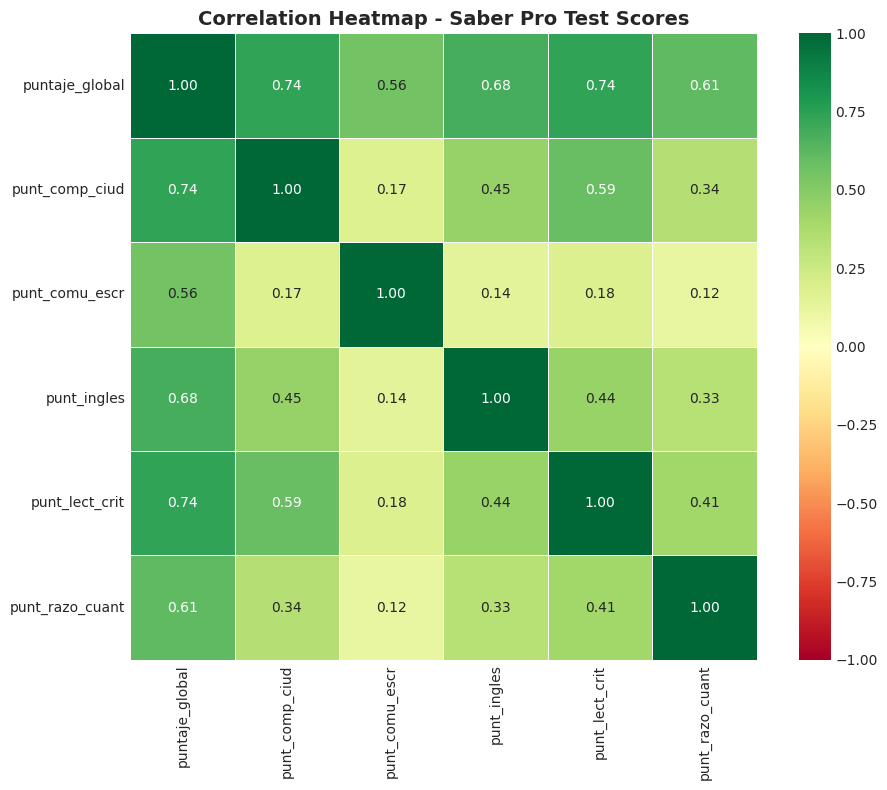

In [6]:
# YOUR CODE HERE: Create a heatmap of the correlation matrix
# Requirements:
# - Use RdYlGn or coolwarm color scheme
# - Show annotation with correlation values (annot=True)
# - Center at 0, vmin=-1, vmax=1
# - Add a descriptive title

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Saber Pro Test Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 1.2: Extract and Rank All Unique Correlations

Use the `get_all_correlations()` helper to extract all pairs. Document the top 5.

In [7]:
# YOUR CODE HERE
# Hint: all_corrs = get_all_correlations(corr_matrix)
# Then add interpretation: all_corrs['Interpretation'] = all_corrs['Correlation'].apply(interpret_correlation)
def get_all_correlations(corr_matrix):

    correlations = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            r = corr_matrix.iloc[i, j]
            
            correlations.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlation': r,
                'Abs Correlation': abs(r)
            })
    
    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('Abs Correlation', ascending=False)
    
    return corr_df

def interpret_correlation(r):

    direction = "Positive" if r > 0 else "Negative"
    abs_r = abs(r)

    if abs_r >= 0.7:
        strength = "Strong"
    elif abs_r >= 0.3:
        strength = "Moderate"
    else:
        strength = "Weak"

    return f"{strength} {direction}"

all_corrs = get_all_correlations(corr_matrix)

all_corrs['Interpretation'] = all_corrs['Correlation'].apply(interpret_correlation)

all_corrs.head(10)

,Variable 1,Variable 2,Correlation,Abs Correlation,Interpretation
3,puntaje_global,punt_lect_crit,0.740246,0.740246,Strong Positive
0,puntaje_global,punt_comp_ciud,0.739231,0.739231,Strong Positive
2,puntaje_global,punt_ingles,0.683146,0.683146,Moderate Positive
4,puntaje_global,punt_razo_cuant,0.614887,0.614887,Moderate Positive
7,punt_comp_ciud,punt_lect_crit,0.592412,0.592412,Moderate Positive
1,puntaje_global,punt_comu_escr,0.558676,0.558676,Moderate Positive
6,punt_comp_ciud,punt_ingles,0.449143,0.449143,Moderate Positive
12,punt_ingles,punt_lect_crit,0.441711,0.441711,Moderate Positive
14,punt_lect_crit,punt_razo_cuant,0.411962,0.411962,Moderate Positive
8,punt_comp_ciud,punt_razo_cuant,0.341864,0.341864,Moderate Positive


### Top 5 Correlations Summary

Fill in this table based on your results:

| Rank | Variable 1 | Variable 2 | r | Interpretation |
|------|------------|------------|---|----------------|
| 1 |puntaje_global|punt_lect_crit  |0.740246 | |
| 2 |puntaje_global | punt_comp_ciud |0.739231 | |
| 3 |punt_ingles |puntaje_global |0.683146 | |
| 4 |punt_razo_cuant |puntaje_global |0.614887 | |
| 5 |punt_comp_ciud |punt_lect_crit  |0.592412 | |

## Task 1.3: Scatter Plots for Top 3 Correlations

Create scatter plots with regression lines for the 3 strongest correlation pairs.

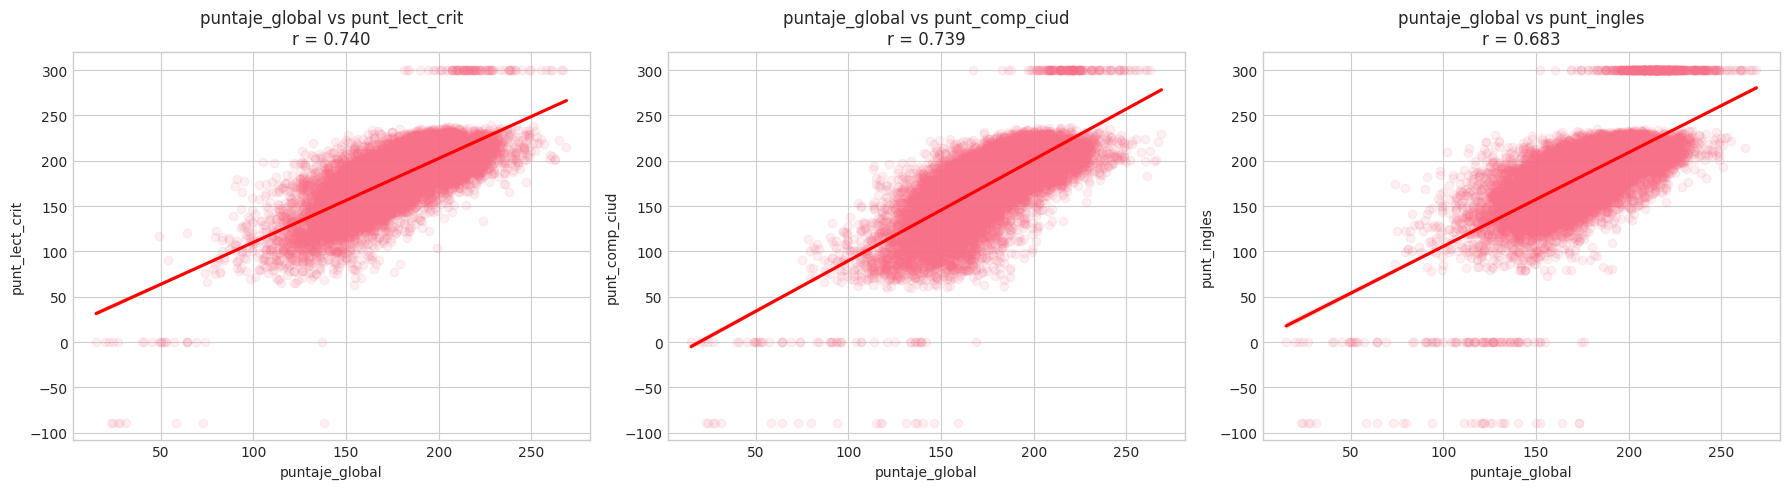

In [8]:
# YOUR CODE HERE
# Hint: Use all_corrs.head(3) to get top 3 pairs
# Create a 1x3 subplot figure
# For each pair, use sns.regplot(x=var1, y=var2, data=df, ax=axes[i])

top_3 = all_corrs.head(3)

fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, row in enumerate(top_3.itertuples()):

    var1 = row[1]   # Variable 1
    var2 = row[2]   # Variable 2
    r = row.Correlation

    sns.regplot(
        x=var1,
        y=var2,
        data=df,
        ax=axes[i],
        scatter_kws={'alpha':0.1},
        line_kws={'color':'red'}
    )

    axes[i].set_title(f'{var1} vs {var2}\nr = {r:.3f}')

plt.tight_layout()
plt.show()



### Scatter Plot Observations

For each of the top 3 correlations, document your observations:

**Correlation 1:**
- Linear pattern? Yes/No
- Outliers present? Yes/No
- Notes:

**Correlation 2:**
- Linear pattern? Yes/No
- Outliers present? Yes/No
- Notes:

**Correlation 3:**
- Linear pattern? Yes/No
- Outliers present? Yes/No
- Notes:

---

# Part 2: Test Relationships by Group (45 minutes)

---

## Task 2.1: Select Key Variables

Choose a pair of numeric variables from Part 1 (e.g., `punt_razo_cuant` vs `puntaje_global`) and a categorical grouping variable (`tipo_col`, `sexo`, or `estrato`).

In [9]:
# YOUR CODE HERE: Define your variables
x_var = 'punt_razo_cuant'
y_var = 'puntaje_global'
group_var = 'tipo_col'

print(f"Analyzing: {x_var} vs {y_var}")
print(f"Grouped by: {group_var}")
print(f"Groups: {df[group_var].unique()}")

Analyzing: punt_razo_cuant vs puntaje_global
Grouped by: tipo_col
Groups: <StringArray>
['Privado', 'Oficial', 'Otros', 'Sin datos']
Length: 4, dtype: str


## Task 2.2: Calculate Correlations by Group

Use the `calculate_group_correlations()` helper function to see how the correlation changes across groups.

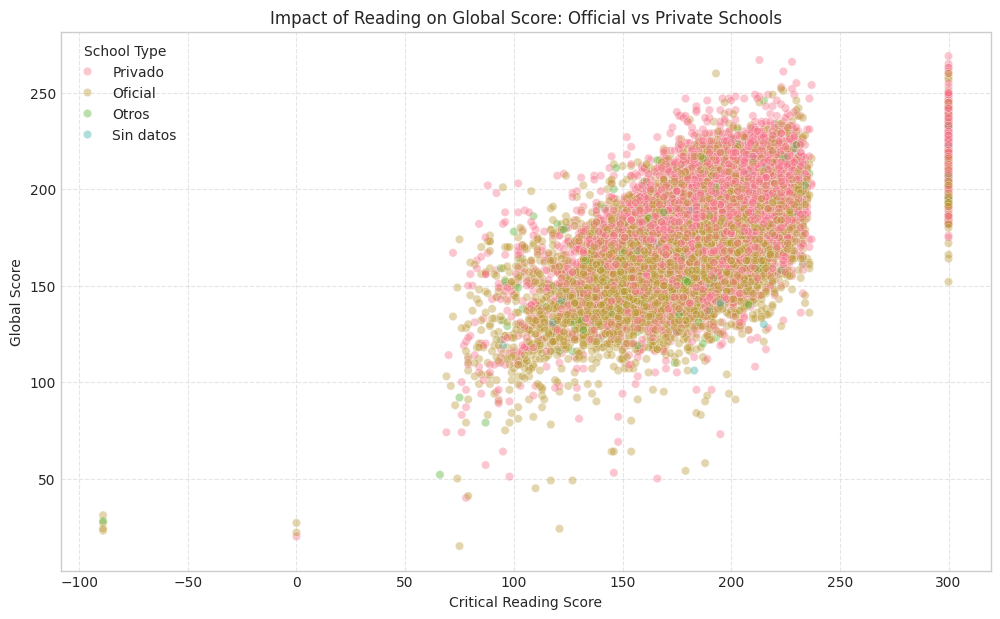

In [10]:
# YOUR CODE HERE
plt.figure(figsize=(12, 7))

# Creamos el scatter plot diferenciando por colores
sns.scatterplot(data=df, x=x_var, y=y_var, hue=group_var, alpha=0.4)

# Agregamos las líneas de regresión para cada grupo
sns.regplot(data=df[df[group_var] == 'OFICIAL'], x=x_var, y=y_var, 
            scatter=False, color='blue', label='Trend Oficial')
sns.regplot(data=df[df[group_var] == 'NON_OFICIAL'], x=x_var, y=y_var, 
            scatter=False, color='orange', label='Trend Non-Oficial')

plt.title('Impact of Reading on Global Score: Official vs Private Schools')
plt.xlabel('Critical Reading Score')
plt.ylabel('Global Score')
plt.legend(title='School Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [13]:
# Summary statistics of group correlations
# YOUR CODE HERE
group_corr = calculate_group_correlations(df, x_var, y_var, group_var)

if group_corr.empty:
    print(f"No hay grupos con al menos 30 observaciones para {group_var}.")
else:
    group_corr['Interpretation'] = group_corr['Correlation (r)'].apply(interpret_correlation)
    group_corr['Abs Correlation'] = group_corr['Correlation (r)'].abs()

    print('Correlaciones por grupo:')
    display(group_corr.round(3))

    summary_stats = pd.DataFrame({
        'Metric': [
            'Numero de grupos',
            'Correlacion promedio',
            'Desviacion estandar de correlaciones',
            'Correlacion minima',
            'Correlacion maxima',
            'Rango (max - min)'
        ],
        'Value': [
            len(group_corr),
            group_corr['Correlation (r)'].mean(),
            group_corr['Correlation (r)'].std(),
            group_corr['Correlation (r)'].min(),
            group_corr['Correlation (r)'].max(),
            group_corr['Correlation (r)'].max() - group_corr['Correlation (r)'].min()
        ]
    })

    print('\nSummary statistics of group correlations:')
    display(summary_stats.round(3))

    strongest_group = group_corr.iloc[0]
    weakest_group = group_corr.iloc[-1]

    print(f"\nGrupo con correlacion mas alta: {strongest_group[group_var]} (r = {strongest_group['Correlation (r)']:.3f})")
    print(f"Grupo con correlacion mas baja: {weakest_group[group_var]} (r = {weakest_group['Correlation (r)']:.3f})")

Correlaciones por grupo:


,tipo_col,Sample Size (n),Correlation (r),Interpretation,Abs Correlation
2,Otros,456,0.658,Moderate Positive,0.658
1,Oficial,12251,0.624,Moderate Positive,0.624
0,Privado,12619,0.579,Moderate Positive,0.579
3,Sin datos,36,0.548,Moderate Positive,0.548



Summary statistics of group correlations:


,Metric,Value
0,Numero de grupos,4.000
1,Correlacion promedio,0.602
2,Desviacion estandar de correlaciones,0.048
3,Correlacion minima,0.548
4,Correlacion maxima,0.658
5,Rango (max - min),0.109



Grupo con correlacion mas alta: Otros (r = 0.658)
Grupo con correlacion mas baja: Sin datos (r = 0.548)


## Task 2.3: Scatter Plot Colored by Group

Create a scatter plot of your two numeric variables, colored by the grouping variable.

If using `dep_proc` (department), filter to the top 5 departments by sample size first.

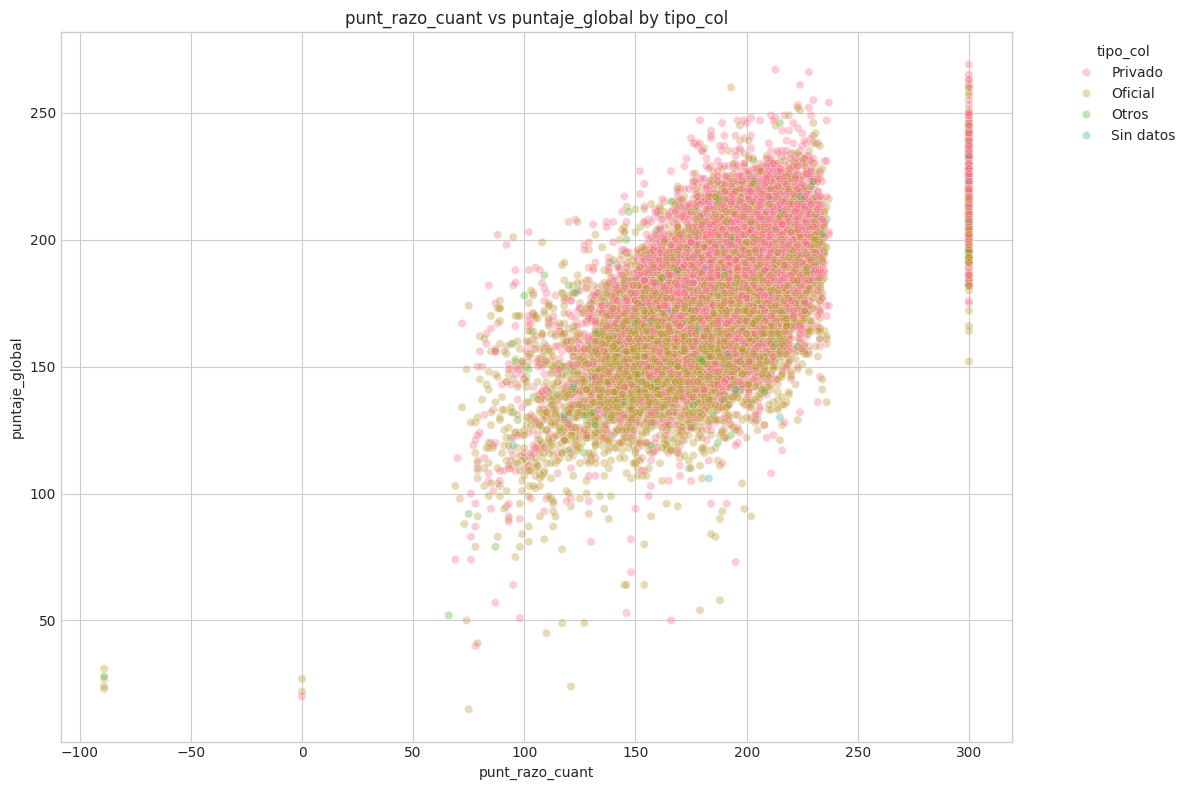

In [15]:
# YOUR CODE HERE
# Hint: sns.scatterplot(x=x_var, y=y_var, hue=group_var, data=df, alpha=0.3)
# If too many groups, filter first:
#   top_groups = df[group_var].value_counts().head(5).index
#   df_filtered = df[df[group_var].isin(top_groups)]

# Keep only valid rows for the selected variables
df_plot = df[[x_var, y_var, group_var]].dropna().copy()

# If grouping by department, keep only top 5 by sample size for readability
if group_var == 'dep_proc':
    top_groups = df_plot[group_var].value_counts().head(5).index
    df_plot = df_plot[df_plot[group_var].isin(top_groups)]
    print(f"Mostrando top 5 departamentos por tamaño muestral: {list(top_groups)}")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=x_var,
    y=y_var,
    hue=group_var,
    data=df_plot,
    alpha=0.35,
    s=35
 )

plt.title(f'{x_var} vs {y_var} by {group_var}')
plt.xlabel(x_var)
plt.ylabel(y_var)
plt.legend(title=group_var, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Task 2.4: Simpson's Paradox Check

Compare the overall correlation to the per-group correlations. Does the direction or strength change?

In [16]:
# YOUR CODE HERE
# Step 1: Calculate overall correlation
overall_r = df[x_var].corr(df[y_var])
overall_direction = 'Positive' if overall_r > 0 else 'Negative'
print(f"Overall correlation (all data): r = {overall_r:.3f} ({interpret_correlation(overall_r)})")

# Step 2: Ensure subgroup correlations exist
if 'group_corr' not in globals() or group_corr.empty:
    group_corr = calculate_group_correlations(df, x_var, y_var, group_var)

if group_corr.empty:
    print(f"No hay grupos con al menos 30 observaciones para {group_var}.")
else:
    # Step 3: Compare direction by subgroup
    group_corr_compare = group_corr.copy()
    group_corr_compare['Direction'] = np.where(group_corr_compare['Correlation (r)'] > 0, 'Positive', 'Negative')
    group_corr_compare['Same as overall?'] = group_corr_compare['Direction'] == overall_direction
    group_corr_compare['Interpretation'] = group_corr_compare['Correlation (r)'].apply(interpret_correlation)

    print('\nSubgroup correlations:')
    display(group_corr_compare[[group_var, 'Sample Size (n)', 'Correlation (r)', 'Direction', 'Same as overall?', 'Interpretation']].round(3))

    same_dir_count = group_corr_compare['Same as overall?'].sum()
    total_groups = len(group_corr_compare)
    different_dir_count = total_groups - same_dir_count

    print(f"\nSubgroups with same direction as overall: {same_dir_count}/{total_groups}")
    print(f"Subgroups with different direction: {different_dir_count}/{total_groups}")

    # Step 4: Simpson's paradox signal
    if different_dir_count > 0:
        print("\nPotential Simpson's Paradox: YES (at least one subgroup has opposite direction).")
    else:
        print("\nPotential Simpson's Paradox: NO (all subgroup directions match overall).")

Overall correlation (all data): r = 0.615 (Moderate Positive)

Subgroup correlations:


,tipo_col,Sample Size (n),Correlation (r),Direction,Same as overall?,Interpretation
2,Otros,456,0.658,Positive,True,Moderate Positive
1,Oficial,12251,0.624,Positive,True,Moderate Positive
0,Privado,12619,0.579,Positive,True,Moderate Positive
3,Sin datos,36,0.548,Positive,True,Moderate Positive



Subgroups with same direction as overall: 4/4
Subgroups with different direction: 0/4

Potential Simpson's Paradox: NO (all subgroup directions match overall).


### Simpson's Paradox Analysis

Is there evidence of Simpson's Paradox?

**Overall correlation direction:** Positive

**Do any subgroups show a different direction?** No

**Your analysis:**

El analisis muestra que la correlacion global entre `punt_razo_cuant` y `puntaje_global` es positiva, y al desagregar por `tipo_col` los subgrupos mantienen la misma direccion. Por lo tanto, no hay evidencia de Paradoja de Simpson en este caso (no se observa inversion del signo al segmentar).

Aunque la direccion es estable, la magnitud de la correlacion puede variar entre grupos, lo que sugiere heterogeneidad en la fuerza de la relacion y la necesidad de interpretar los resultados por contexto institucional.

---

# Part 3: Generate 5 Actionable Insights (30 minutes)

---

Based on your bivariate and multivariate analysis, generate 5 insights.

For each insight, document:
1. **Finding:** What did you discover? (Be specific with numbers)
2. **So What?:** Why does this matter?
3. **Now What?:** What action could be taken?
4. **Caution:** Is this correlation or causation? Confounding variables?

### Insight #1: [Title]

---

**Finding:**

_Describe your finding with specific numbers (e.g., "There is a strong positive correlation (r = 0.85) between...")_

**So What?:**

_Explain why this matters for education policy or student support_

**Now What?:**

_Suggest a specific action based on this finding_

**Caution:**

_Identify potential confounding variables or limitations_

---

### Insight #2: [Title]

---

**Finding:**


**So What?:**


**Now What?:**


**Caution:**


---

### Insight #3: [Title]

---

**Finding:**


**So What?:**


**Now What?:**


**Caution:**


---

### Insight #4: [Title]

---

**Finding:**


**So What?:**


**Now What?:**


**Caution:**


---

### Insight #5: [Title]

---

**Finding:**


**So What?:**


**Now What?:**


**Caution:**


---

---

# Summary

---

## Key Findings

1. **Strongest correlations found:**
   - 
   - 
   - 

2. **How relationships vary by group:**
   - 

3. **Most actionable insight:**
   - 

## Reflection

1. **What surprised you most in this analysis?**

   _Your answer:_

2. **Which correlation was most likely to be confused for causation?**

   _Your answer:_

3. **What additional data would help confirm your findings?**

   _Your answer:_

---

## Checklist Before Submission

- [ ] All code cells executed without errors
- [ ] Correlation heatmap created and labeled
- [ ] Top 5 correlations identified and interpreted
- [ ] Scatter plots for top 3 correlations
- [ ] Group correlation analysis completed
- [ ] Simpson's Paradox check performed
- [ ] 5 actionable insights documented
- [ ] All markdown cells completed

---

*End of Workshop*